# GNN Error & Anomaly Analysis vs. Graph Topology

GNN performance and representation structure are deeply tied to the **topology** of the graph. In this notebook, we audit **GCN** and **GraphSAGE** on **Cora** and **Karate Club** by correlating classification errors and anomaly scores against structural node properties:
1. **Node Degree**: The number of connections a node has. Do low-degree nodes (isolated nodes) suffer from poor accuracy due to sparse message-passing, or are they flagged as anomalies?
2. **Neighborhood Homophily**: The fraction of a node's immediate neighbors that share its same class label:
   $$h_v = \frac{\sum_{u \in \mathcal{N}(v)} \mathbb{I}(y_u = y_v)}{|\mathcal{N}(v)|}$$
   Do models consistently fail on heterophilous nodes (nodes connected to different classes)?

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from torch_geometric.utils import degree

from main import load_dataset, build_model, set_seed
from train import train_one_epoch
from test import evaluate
from parameters import ModelParams, TrainParams, DataParams

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Setup complete. Device:', DEVICE)

Setup complete. Device: cuda


## Topological Indices Computations

In [2]:
def compute_neighborhood_homophily(edge_index, y):
    """Compute neighborhood homophily for each node in the graph."""
    num_nodes = y.size(0)
    homophilies = torch.zeros(num_nodes)
    row, col = edge_index
    
    for i in range(num_nodes):
        # Get neighbors
        neighbors = col[row == i]
        if len(neighbors) == 0:
            homophilies[i] = 1.0  # default for isolated nodes
        else:
            neighbor_classes = y[neighbors]
            same_class = (neighbor_classes == y[i]).sum().item()
            homophilies[i] = same_class / len(neighbors)
            
    return homophilies.cpu().numpy()

## Experiment Pipeline

In [3]:
def run_topology_experiment(model_name, dataset_name='cora', epochs=120):
    set_seed(42)
    
    data_params = DataParams(dataset_name=dataset_name, seed=42)
    ds_info = load_dataset(data_params)
    data = ds_info['data'].to(DEVICE)
    train_mask = ds_info['train_mask'].to(DEVICE)
    val_mask = ds_info['val_mask'].to(DEVICE)
    test_mask = ds_info['test_mask'].to(DEVICE)
    
    model_params = ModelParams(model_name=model_name, hidden_channels=64, num_layers=2, dropout=0.5)
    model = build_model(model_params, ds_info['num_features'], ds_info['num_classes'], 'node').to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    
    # Train GNN
    best_val = 0.0
    best_state = None
    for _ in range(epochs):
        train_one_epoch(model, 'node', optimizer, DEVICE, data=data, train_mask=train_mask)
        val_acc = evaluate(model, 'node', DEVICE, data=data, mask=val_mask)['accuracy']
        if val_acc > best_val:
            best_val = val_acc
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            
    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    
    # Evaluate node predictions
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out.argmax(dim=-1).cpu().numpy()
    y_true = data.y.cpu().numpy()
    correct = (pred == y_true)
    
    # Extract GNN Embeddings & Anomaly Scores
    emb = model.embed(data.x, data.edge_index).cpu().numpy()
    iso = IsolationForest(contamination=0.1, random_state=42)
    iso.fit(emb)
    anomaly_scores = -iso.score_samples(emb)
    
    # Compute topological properties
    deg = degree(data.edge_index[0], num_nodes=data.num_nodes).cpu().numpy()
    homophily = compute_neighborhood_homophily(data.edge_index, data.y)
    
    # Compile stats DataFrame
    df = pd.DataFrame({
        'node': range(data.num_nodes),
        'degree': deg,
        'homophily': homophily,
        'correct': correct,
        'anomaly_score': anomaly_scores,
        'test_mask': test_mask.cpu().numpy(),
        'train_mask': train_mask.cpu().numpy()
    })
    return df

## Run Experiments for GCN & GraphSAGE

In [4]:
print('Running topological evaluation for GCN on Cora...')
df_gcn = run_topology_experiment('gcn')

print('Running topological evaluation for GraphSAGE on Cora...')
df_sage = run_topology_experiment('graphsage')

Running topological evaluation for GCN on Cora...


Running topological evaluation for GraphSAGE on Cora...


## Visualizing Topological Auditing Results

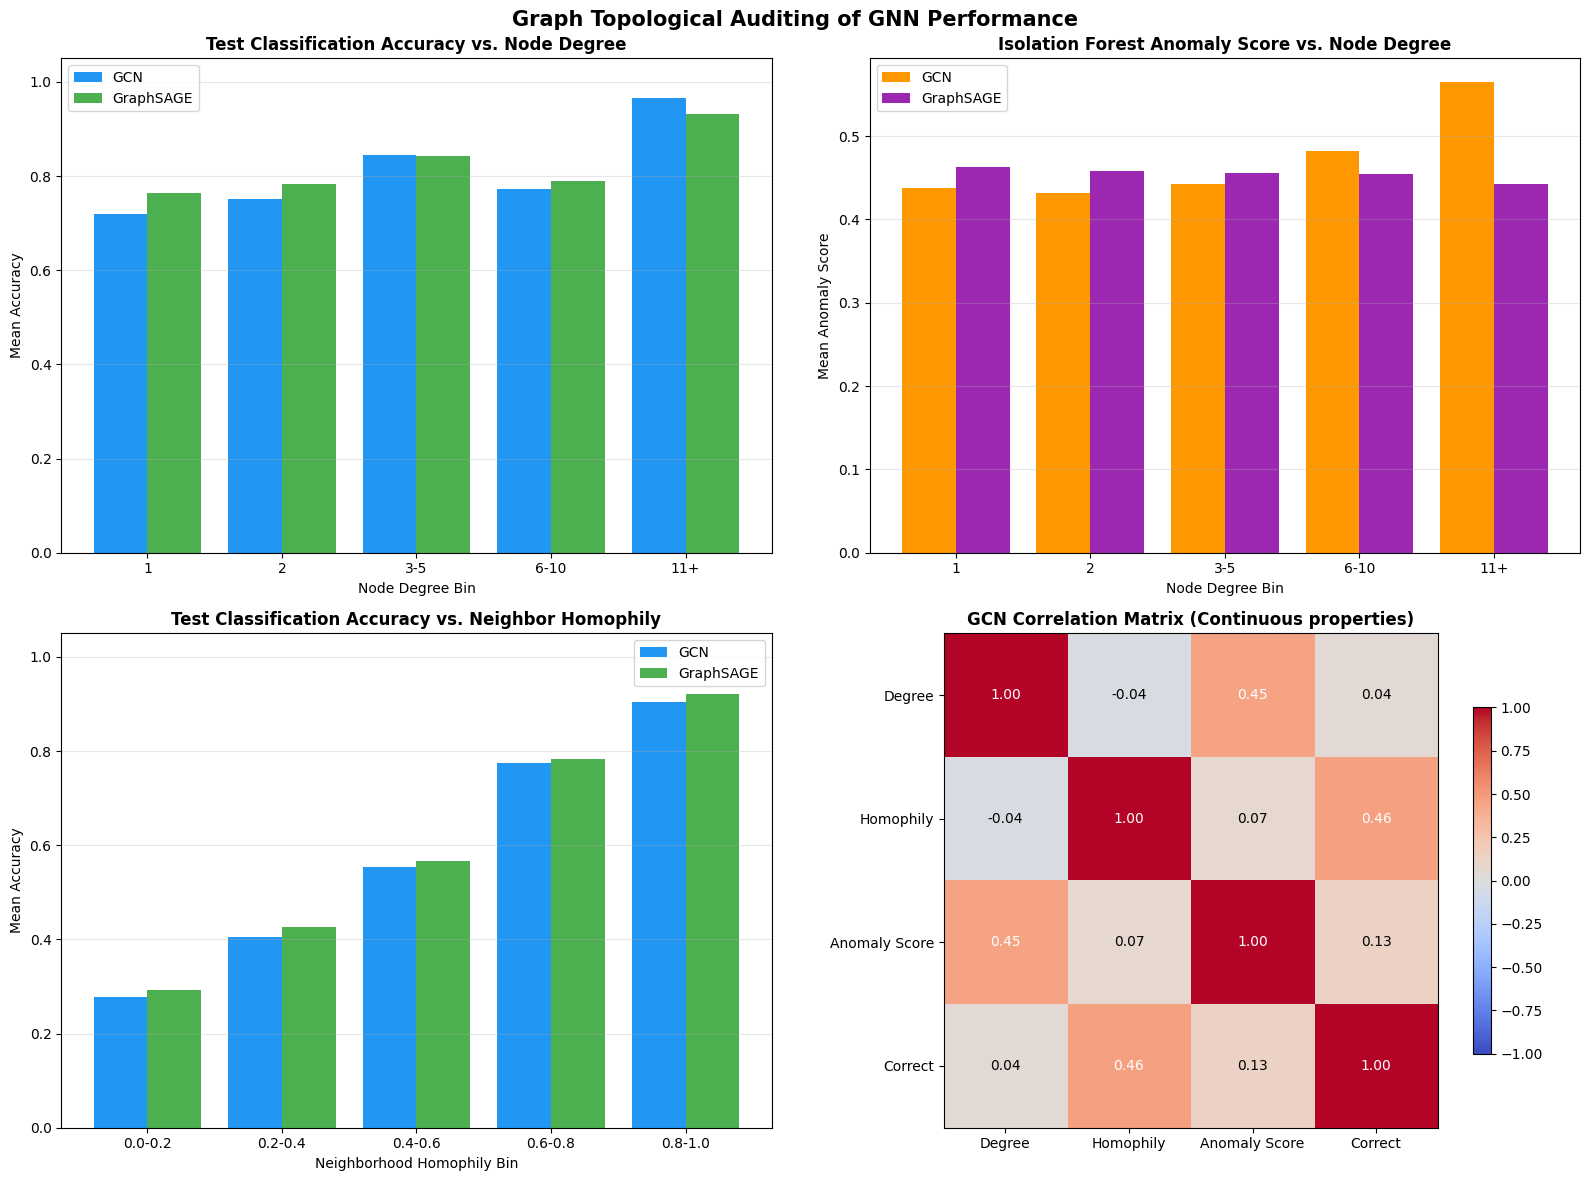

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Binning Degree for Cora
# Node degree bins: 1, 2, 3-5, 6-10, 11+
def bin_degree(d):
    if d == 1: return '1'
    elif d == 2: return '2'
    elif 3 <= d <= 5: return '3-5'
    elif 6 <= d <= 10: return '6-10'
    return '11+'

for df in [df_gcn, df_sage]:
    df['degree_bin'] = df['degree'].apply(bin_degree)
    
deg_order = ['1', '2', '3-5', '6-10', '11+']

# 1. Test Accuracy vs. Node Degree
ax = axes[0, 0]
gcn_acc = df_gcn[df_gcn['test_mask']].groupby('degree_bin')['correct'].mean().loc[deg_order]
sage_acc = df_sage[df_sage['test_mask']].groupby('degree_bin')['correct'].mean().loc[deg_order]
x = np.arange(len(deg_order))
ax.bar(x - 0.2, gcn_acc, 0.4, label='GCN', color='#2196F3')
ax.bar(x + 0.2, sage_acc, 0.4, label='GraphSAGE', color='#4CAF50')
ax.set_title('Test Classification Accuracy vs. Node Degree', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(deg_order)
ax.set_xlabel('Node Degree Bin')
ax.set_ylabel('Mean Accuracy')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, 1.05)

# 2. Anomaly Score vs. Node Degree
ax = axes[0, 1]
gcn_anom = df_gcn.groupby('degree_bin')['anomaly_score'].mean().loc[deg_order]
sage_anom = df_sage.groupby('degree_bin')['anomaly_score'].mean().loc[deg_order]
ax.bar(x - 0.2, gcn_anom, 0.4, label='GCN', color='#FF9800')
ax.bar(x + 0.2, sage_anom, 0.4, label='GraphSAGE', color='#9C27B0')
ax.set_title('Isolation Forest Anomaly Score vs. Node Degree', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(deg_order)
ax.set_xlabel('Node Degree Bin')
ax.set_ylabel('Mean Anomaly Score')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

# Binning Neighborhood Homophily
# Homophily bins: [0, 0.2], (0.2, 0.4], (0.4, 0.6], (0.6, 0.8], (0.8, 1.0]
def bin_homophily(h):
    if h <= 0.2: return '0.0-0.2'
    elif h <= 0.4: return '0.2-0.4'
    elif h <= 0.6: return '0.4-0.6'
    elif h <= 0.8: return '0.6-0.8'
    return '0.8-1.0'

for df in [df_gcn, df_sage]:
    df['homophily_bin'] = df['homophily'].apply(bin_homophily)
    
homo_order = ['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0']

# 3. Test Accuracy vs. Neighborhood Homophily
ax = axes[1, 0]
gcn_homo = df_gcn[df_gcn['test_mask']].groupby('homophily_bin')['correct'].mean().loc[homo_order]
sage_homo = df_sage[df_sage['test_mask']].groupby('homophily_bin')['correct'].mean().loc[homo_order]
x_homo = np.arange(len(homo_order))
ax.bar(x_homo - 0.2, gcn_homo, 0.4, label='GCN', color='#2196F3')
ax.bar(x_homo + 0.2, sage_homo, 0.4, label='GraphSAGE', color='#4CAF50')
ax.set_title('Test Classification Accuracy vs. Neighbor Homophily', fontweight='bold')
ax.set_xticks(x_homo)
ax.set_xticklabels(homo_order)
ax.set_xlabel('Neighborhood Homophily Bin')
ax.set_ylabel('Mean Accuracy')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, 1.05)

# 4. Correlation Heatmap values
ax = axes[1, 1]
# Compute Pearson correlation matrix of continuous properties for GCN
corr_matrix = df_gcn[['degree', 'homophily', 'anomaly_score', 'correct']].corr().values
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(['Degree', 'Homophily', 'Anomaly Score', 'Correct'])
ax.set_yticklabels(['Degree', 'Homophily', 'Anomaly Score', 'Correct'])
ax.set_title('GCN Correlation Matrix (Continuous properties)', fontweight='bold')

# Annotate values
for r in range(4):
    for c in range(4):
        ax.text(c, r, f'{corr_matrix[r, c]:.2f}', ha='center', va='center',
                color='black' if -0.3 < corr_matrix[r, c] < 0.3 else 'white')
fig.colorbar(im, ax=ax, shrink=0.7)

plt.suptitle('Graph Topological Auditing of GNN Performance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('topology_property_analysis.png', dpi=120, bbox_inches='tight')
plt.show()